# SPISEA Quick Start: Making A Cluster with Brown Dwarfs

This is a quick start guide to making a synthetic cluster using the SPISEA package, with the recent addition of brown dwarf capabilities. The cluster is constructed using a user-specified isochrone and initial mass function (IMF). Detailed documentation is provided in the ReadtheDocs page (https://spisea.readthedocs.io/en/latest/index.html).

Before starting this tutorial, it is assumed that SPISEA has been installed and the user's python path has been altered to include the SPISEA top-level directory

In [1]:
# Import necessary packages. 
from spisea import synthetic, evolution, atmospheres, reddening, ifmr
from spisea.imf import imf, multiplicity
import numpy as np
import pylab as py
import pdb
import matplotlib.pyplot as plt
from astropy.table import vstack
%matplotlib inline

#### Step 1: Make a SPISEA isochrone object

The cluster is made from a theoretical isochrone at a given age, extinction, and distance from Earth. These parameters MUST be specified by the user. Other inputs (e.g. stellar evolution/atmosphere models, extinction law, and photometric filters used) are optional keywords. See documentation for all keywords and their default values.

Important Note: The IsochronePhot class saves its output as a FITS table, which it will read on subsequent calls for the same isochrone rather than regenerating it from scratch. We highly recommend reading the "Tips and Tricks: The IsochronePhot Object" section of the Isochrone object documentation for details on how this process works.

Here, we create a 5 Myr cluster isochrone at an extinction of 0.8 mags and distance of 4000 pc from Earth. 

In [2]:
# Define isochrone parameters
logAge = np.log10(5*10**6.) # Age in log(years)
AKs = 0.8 # extinction in mags
dist = 4000 # distance in parsec
metallicity = 0 # Metallicity in [M/H]

# Define brown dwarf supported evolution/atmosphere models and extinction law
evo_model = evolution.MergedPhillipsBaraffePisaEkstromParsec() 
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawHosek18b()

# Also specify filters for synthetic photometry (optional). Here we use 
# the HST WFC3-IR F127M, F139M, and F153M filters
filt_list = ['wfc3,ir,f127m', 'wfc3,ir,f139m', 'wfc3,ir,f153m']

# Specify the directory we want the output isochrone
# table saved in. If the directory does not already exist,
# SPISEA will create it.
iso_dir = 'isochrones/'

# Make IsochronePhot object. Note that this will take a minute or two, 
# unless the isochrone has been generated previously.
#
# Note that this is not show all of the user options 
# for IsochronePhot. See docs for complete list of options.
my_iso = synthetic.IsochronePhot(logAge, AKs, dist, metallicity=0,
                            evo_model=evo_model, atm_func=atm_func,
                            red_law=red_law, filters=filt_list,
                                iso_dir=iso_dir)

Once calculated, the isochrone will be written as a fits file to a location set by the "iso_dir" keyword (note: if iso_dir is not defined, the isochrone is saved in the current working directory by default). In the future, the IsochronePhot function will read this file directly rather than recalculating the isochrone again. 

The output file is named as: "iso_logAge_AKs_distance_metallicity.fits, using the specified values

In [3]:
# The stars in the isochrone and associated properties  
# are stored in an astropy table called "points" 
# within the IsochronePhot object. 
print(my_iso.points)

          L                   Teff                R            mass   logg   isWR mass_current phase    m_hst_f127m        m_hst_f139m        m_hst_f153m    
          W                    K                  m          solMass                solMass                                                                  
---------------------- ------------------ ------------------ ------- ------ ----- ------------ ----- ------------------ ------------------ ------------------
2.5969998772673413e+20 432.41425250986447 102099864.14758782  0.0005 2.8027 False       0.0005     1  33.96148101996776 41.349910373359705   34.0979568030492
 8.992323640770438e+20  594.8397740692212 100398023.76104526   0.001 3.1183 False        0.001     1 31.543816736848385 37.485693950053815  31.74912432063749
3.7824389676866323e+21  848.3987109859956 101222058.29958254   0.002  3.412 False        0.002     1 29.766073130622274  33.63286970536957  29.89254633083153
 8.832261707714201e+21 1038.2453626533147 103282124.

In [4]:
# The isochrone table has meta keywords describing its input properties:
# REDLAW: which redlaw object was used
# ATMFUNC: atmosphere grid was used
# EVOMODEL: evolution model grid used
# LOGAGE: log(Age) of isochrone
# AKS: total extinction used
# DISTANCE: distance used
# METAL_IN: metallicity requested by user, in [M/H]
# METAL_ACT: actual metallicity of model, in [M/H] 
# (only relevant if user chooses metallicity other than defined grid-points)
# WAVEMIN, WAVEMAX: the minimum and maximum wavelengths of the stellar spectra (angstroms)
print(my_iso.points.meta)

OrderedDict([('REDLAW', 'H18b'), ('ATMFUNC', 'get_merged_atmosphere'), ('EVOMODEL', 'MergedPhillipsBaraffePisaEkstromParsec'), ('LOGAGE', 6.698970004336019), ('AKS', 0.8), ('DISTANCE', 4000), ('METAL_IN', 0), ('METAL_ACT', 0.0), ('WAVEMIN', 3000), ('WAVEMAX', 52000)])


In [5]:
# See Isochrone Object documentation for column definitions
print('The columns in the isochrone table are: {0}'.format(my_iso.points.keys()))

The columns in the isochrone table are: ['L', 'Teff', 'R', 'mass', 'logg', 'isWR', 'mass_current', 'phase', 'm_hst_f127m', 'm_hst_f139m', 'm_hst_f153m']


In [6]:
# Example case:
# Identify a 1 M_sun star, print F127M, F139M, and F153M mags
idx = np.where( abs(my_iso.points['mass'] - 1.0) == min(abs(my_iso.points['mass'] - 1.0)) )[0]
f127m = np.round(my_iso.points[idx[0]]['m_hst_f127m'], decimals=3)
f139m = np.round(my_iso.points[idx[0]]['m_hst_f139m'], decimals=3)
f153m = np.round(my_iso.points[idx[0]]['m_hst_f153m'], decimals=3)
print('1 M_sun: F127M = {0} mag, F139M = {1} mag, F153M = {2} mag'.format(f127m, f139m, f153m))

1 M_sun: F127M = 19.051 mag, F139M = 18.453 mag, F153M = 17.785 mag


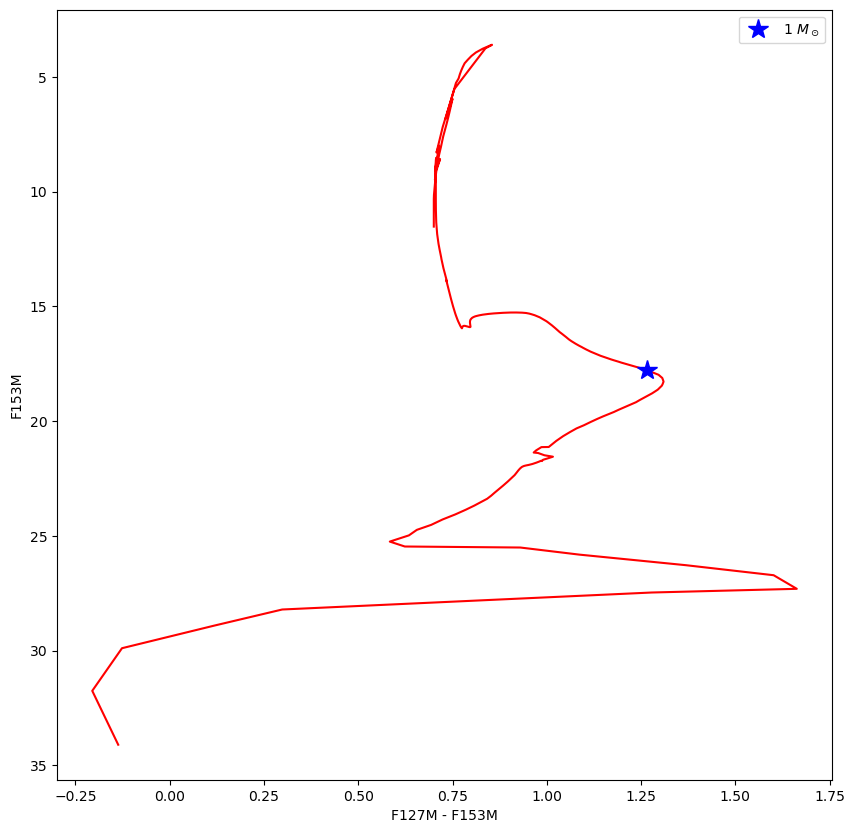

In [7]:
# Make a color-magnitude diagram from the isochrone
py.figure(1, figsize=(10,10))
py.clf()
py.plot(my_iso.points['m_hst_f127m'] - my_iso.points['m_hst_f153m'], 
       my_iso.points['m_hst_f153m'], 'r-', label='_nolegend_')
py.plot(my_iso.points['m_hst_f127m'][idx] - my_iso.points['m_hst_f153m'][idx], 
       my_iso.points['m_hst_f153m'][idx], 'b*', ms=15, label='1 $M_\odot$')
py.xlabel('F127M - F153M')
py.ylabel('F153M')
py.gca().invert_yaxis()
py.legend()

### Step 2: Make an Initial Mass Function

SPISEA offers a range of initial mass functions (IMFs) a user can use from to make the cluster. In addition to the parameters defining the IMF, the user can input a SPISEA multiplicity object, which defines the multiplicity properties of the population. The default multiplicity is None (e.g. all stars are single).

Here we define a Kirkpatrick and Salpeter IMF using the Multiplicity properties defined in Lu+13 and Begbie+26. 

In [8]:
# Make multiplicity object Here, we use the MultiplicityUnresolved object, 
# based on Lu+13. This means that star systems will be unresolved, i.e., 
# that all components of a star system are combined into a single "star" in the cluster
imf_multi = multiplicity.MultiplicityUnresolved()

# Make IMF object; we'll use a broken power law with the parameters from Kroupa+01

# NOTE: when defining the power law slope for each segment of the IMF, we define
# the entire exponent, including the negative sign. For example, if dN/dm $\propto$ m^-alpha,
# then you would use the value "-2.3" to specify an IMF with alpha = 2.3. 

massLimits = np.array([0.01, 0.05, 0.22, 0.55, 8, 120]) # Define boundaries of each mass segement
powers = np.array([-0.6, -0.25, -1.3, -2.3, -2.35]) # Power law slope associated with each mass segment
my_imf = imf.IMF_broken_powerlaw(massLimits, powers, imf_multi)

### Step 3: Make the Cluster  
#### Option 1: Resolved Cluster without compact objects

Here we make a resolved cluster using the ResolvedCluster object. 

To create the cluster, the user passes in an isochrone object, and imf object, and specifies the total cluster mass. Here we will make a 10^5 M_sun cluster using the isochrone and imf we have defined. 

###### Some Notes
1. Unless an IFMR object is defined, no compact objects are included. Stars that have evolved into compact objects will be dropped from the cluster. 
2. Stars generated by the IMF object that have masses below the lowest mass in the evolution model are dropped from the cluster.
2. If you wish to create a cluster with differential extinction included in the output photometry, then you can use the ResolvedClusterDiffRedden object. It is the same as ResolvedCluster, but with an additional parameter to define dAKs, which characterizes the spread of extinction within the cluster

In [9]:
# Define total cluster mass
mass = 10**5.

# Make cluster object
cluster = synthetic.ResolvedCluster(my_iso, my_imf, mass)

Found 30 stars out of mass range


The individual stars (or star systems) in the cluster are stored in an astropy table called "star_systems" within the cluster object. If a multiplicity object is used, then an additional "companions" table is created that contains the properties of the companions to the primary star within each star system. See cluster object documentation for a description of the columns in these tables. 

If a multiplicity object is used, then the photometry in the star_systems table is the COMBINED photometry of the system; it includes the contributions from all companions.

In [10]:
# Look at star systems table
print(cluster.star_systems)

        mass         isMultiple      systemMass             Teff                  L            ... metallicity    m_hst_f127m        m_hst_f139m        m_hst_f153m     N_companions
-------------------- ---------- -------------------- ------------------ ---------------------- ... ----------- ------------------ ------------------ ------------------ ------------
  0.8945070753124857      False   0.8945070753124857  4225.696580422644 2.0017761931081406e+26 ...         0.0 19.243056683615986 18.637173365678077  17.95084609292932            0
  0.9214480579938956      False   0.9214480579938956  4261.931211189814  2.116376266341599e+26 ...         0.0  19.19230771149491 18.588166309349045 17.906424455244924            0
 0.10024865234106253      False  0.10024865234106253 3027.3930442939845  8.920168492066747e+24 ...         0.0 22.126796830827757 21.771742516715804 21.121481298455976            0
 0.10331038960864716      False  0.10331038960864716 3033.2987146970418  9.299161930812652e+24 

In [11]:
print('The cluster table contains these columns: {0}'.format(cluster.star_systems.keys()))

The cluster table contains these columns: ['mass', 'isMultiple', 'systemMass', 'Teff', 'L', 'logg', 'isWR', 'mass_current', 'phase', 'metallicity', 'm_hst_f127m', 'm_hst_f139m', 'm_hst_f153m', 'N_companions']


In [12]:
# The companions table is accessed in a similar way
print(cluster.companions)

system_idx         mass                Teff                  L                   logg        isWR ... phase metallicity    m_hst_f127m        m_hst_f139m        m_hst_f153m    
---------- -------------------- ------------------ ---------------------- ------------------ ---- ... ----- ----------- ------------------ ------------------ ------------------
         4   0.9777597710995893  4338.028423554631  2.376440000333853e+26  4.144613121985373  0.0 ...   1.0         0.0 19.086957934184962 18.486987528104535  17.81521684302705
        11  0.15460670216753916 3132.2066605872137 1.5646612433306536e+25  3.965782010650262  0.0 ...   1.0         0.0 21.575780039801344  21.16920821774943 20.518870336074574
        15  0.14437684590811475  3112.343343205245  1.437991304956611e+25 3.9627130537724344  0.0 ...   1.0         0.0  21.65960932490563 21.261309867319465  20.61225231261144
        17   0.4650204014154078 3654.3377635407696  7.089917157017561e+25  4.045880610389237  0.0 ...   1.0        

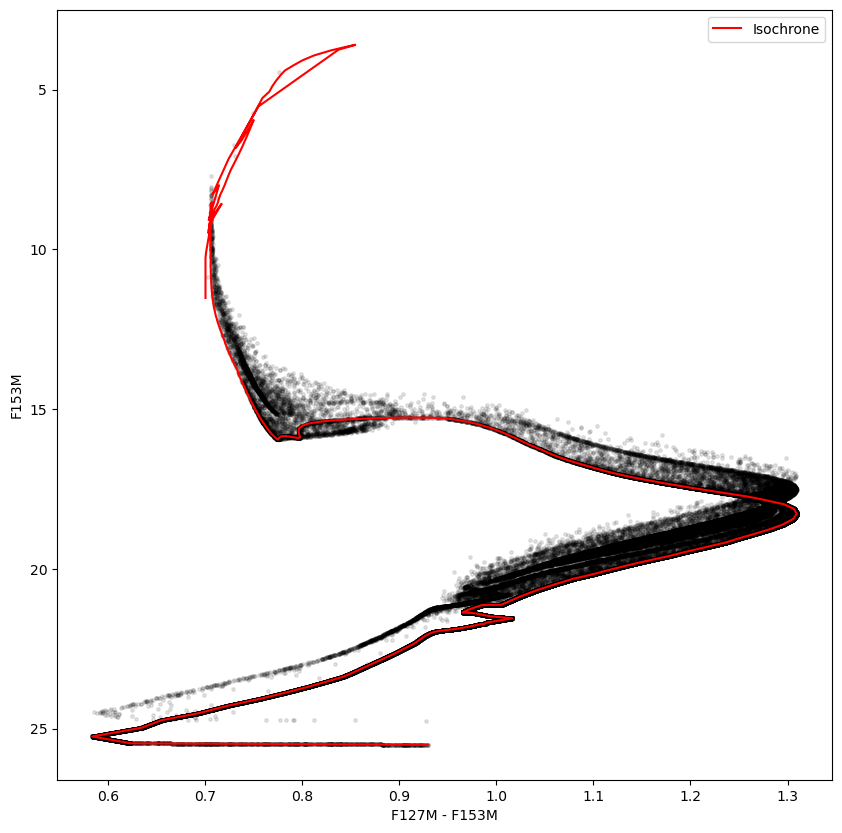

In [13]:
# Look at the cluster CMD, compared to input isochrone. Note the impact of
# multiple systems on the photometry

clust = cluster.star_systems
iso = my_iso.points

# specify mask to only extend isochrone to brown dwarf masses
bds = iso['mass'] >= 0.01

py.figure(2, figsize=(10,10))
py.clf()
py.plot(clust['m_hst_f127m'] - clust['m_hst_f153m'], clust['m_hst_f153m'],
       'k.', ms=5, alpha=0.1, label='__nolegend__')
py.plot(iso['m_hst_f127m'][bds] - iso['m_hst_f153m'][bds], iso['m_hst_f153m'][bds],
       'r-', label='Isochrone')
py.xlabel('F127M - F153M')
py.ylabel('F153M')
py.gca().invert_yaxis()
py.legend()

#### Option 2: Resolved cluster with compact objects (white dwarfs, neutron stars, and black holes)
This is quite similar to the above, but includes compact objects. The additional piece of information required is to choose an initial-final mass relation (IFMR.)

The output is the same as if we were making a cluster without using an IFMR. However, you can tell that compact objects are made by looking at the 'phase' keyword. Black holes have 'phase' = 103, neutron stars have 'phase' = 102, and white dwarfs have 'phase' = 101. Though not classified as a compact object, brown dwarfs have 'phase' = 90. For these compact objects (black holes, neutron stars, white dwarfs), the luminosity and temperature will return values of zero, and photometry will return nan, since we are assuming they are totally dark.

Here, we make 4 different clusters, each of mass $10^6 M_\odot$, by taking different combinations of age (either 100 Myr or 10 Gyr) and IMF (top-heavy or Kroupa). We then look at the different distributions of BH and WD masses. 

In [14]:
# Create isochrone object  
filt_list = ['wfc3,ir,f153m'] # We won't be doing much with synthetic photometry here, so only 1 filter
my_ifmr = ifmr.IFMR_Raithel18()
my_iso_young = synthetic.IsochronePhot(8, 0, 10,
                                 evo_model = evolution.MergedPhillipsBaraffePisaEkstromParsec(),
                                      filters=filt_list)

my_iso_old = synthetic.IsochronePhot(10, 0, 10,
                                 evo_model = evolution.MergedPhillipsBaraffePisaEkstromParsec(),
                                    filters=filt_list)

In [15]:
# Create IMF objects                                                                                                                                                     
massLimits = np.array([0.01, 0.05, 0.1, 0.5, 120])
powers_kroupa = np.array([-0.6, -0.25, -1.3, -2.3])
powers_theavy = np.array([-0.6, -0.25, -1.3, -1.3]) # top heavy
trunc_kroupa = imf.IMF_broken_powerlaw(massLimits, powers_kroupa)
trunc_theavy = imf.IMF_broken_powerlaw(massLimits, powers_theavy)

In [16]:
# Make clusters                                                                                                                                                          
cluster_mass = 10**6
cluster_young_theavy = synthetic.ResolvedCluster(my_iso_young, trunc_theavy, cluster_mass, ifmr=my_ifmr)
cluster_old_theavy = synthetic.ResolvedCluster(my_iso_old, trunc_theavy, cluster_mass, ifmr=my_ifmr)
cluster_young_kroupa = synthetic.ResolvedCluster(my_iso_young, trunc_kroupa, cluster_mass, ifmr=my_ifmr)
cluster_old_kroupa = synthetic.ResolvedCluster(my_iso_old, trunc_kroupa, cluster_mass, ifmr=my_ifmr)

# Get the outputs
young_theavy = cluster_young_theavy.star_systems
old_theavy = cluster_old_theavy.star_systems
young_kroupa = cluster_young_kroupa.star_systems
old_kroupa = cluster_old_kroupa.star_systems

/u/caitlinbegbie/.local/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


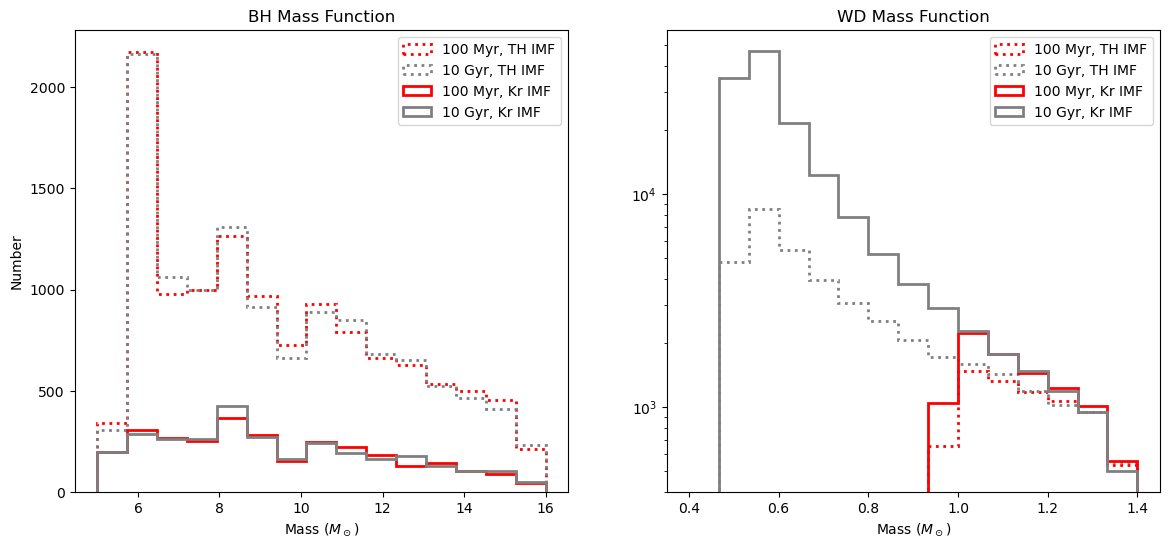

In [17]:
young_theavy_bh_idx = np.where(young_theavy['phase'] == 103)[0]
old_theavy_bh_idx = np.where(old_theavy['phase'] == 103)[0]
young_kroupa_bh_idx = np.where(young_kroupa['phase'] == 103)[0]
old_kroupa_bh_idx = np.where(old_kroupa['phase'] == 103)[0]

bh_bins = np.linspace(5, 16, 16)
wd_bins = np.linspace(0.4, 1.4, 16)

plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
plt.hist(young_theavy[young_theavy_bh_idx]['mass_current'], histtype = 'step',
        bins = bh_bins, label = '100 Myr, TH IMF', color = 'red', linestyle = ':', lw = 2)
plt.hist(old_theavy[old_theavy_bh_idx]['mass_current'], histtype = 'step',
        bins = bh_bins, label = '10 Gyr, TH IMF', color = 'gray', linestyle = ':', lw = 2)
plt.hist(young_kroupa[young_kroupa_bh_idx]['mass_current'], histtype = 'step',
        bins = bh_bins, label = '100 Myr, Kr IMF', color = 'red', lw = 2)
plt.hist(old_kroupa[old_kroupa_bh_idx]['mass_current'], histtype = 'step',
        bins = bh_bins, label = '10 Gyr, Kr IMF', color = 'gray', lw = 2)
plt.title('BH Mass Function')
plt.xlabel('Mass ($M_\odot$)')
plt.ylabel('Number')
plt.legend()

young_theavy_wd_idx = np.where(young_theavy['phase'] == 101)[0]
old_theavy_wd_idx = np.where(old_theavy['phase'] == 101)[0]
young_kroupa_wd_idx = np.where(young_kroupa['phase'] == 101)[0]
old_kroupa_wd_idx = np.where(old_kroupa['phase'] == 101)[0]

plt.subplot(1, 2, 2)
plt.hist(young_theavy[young_theavy_wd_idx]['mass_current'], histtype = 'step',
        bins = wd_bins, label = '100 Myr, TH IMF', color = 'red', linestyle = ':', lw = 2)
plt.hist(old_theavy[old_theavy_wd_idx]['mass_current'], histtype = 'step',
        bins = wd_bins, label = '10 Gyr, TH IMF', color = 'gray', linestyle = ':', lw = 2)
plt.hist(young_kroupa[young_kroupa_wd_idx]['mass_current'], histtype = 'step',
        bins = wd_bins, label = '100 Myr, Kr IMF', color = 'red', lw = 2)
plt.hist(old_kroupa[old_kroupa_wd_idx]['mass_current'], histtype = 'step',
        bins = wd_bins, label = '10 Gyr, Kr IMF', color = 'gray', lw = 2)
plt.yscale('log')
plt.title('WD Mass Function')
plt.xlabel('Mass ($M_\odot$)')
plt.legend()

Plotted above are the distributions of BH and WD masses for clusters of different ages (100 Myr or 10 Gyr), with either a top-heavy or Kroupa IMF. For BHs, since those are formed relatively early on, the age of the cluster does not significantly change the mass distribution as most BHs have already formed by 100 Myr. However, the top heavy IMF allows the creation of many more massive compact objects. For WDs, both the age and IMF make significant differences in the distribution (note y-axis is logscaled).

## Explicitly Showing Brown Dwarfs in Simulated Clusters

Here we are creating a cluster of log(age) = 8.4 with brown dwarfs. We show where they fall on the generated isochrone and how they incorporate into clusters.

In [18]:
# Create isochrone object  
filt_list = ['wfc3,ir,f153m'] # Only 1 filter for plotting purposes
my_ifmr = ifmr.IFMR_Raithel18()
my_iso = synthetic.IsochronePhot(8.4, 0, 10,
                                 evo_model = evolution.MergedPhillipsBaraffePisaEkstromParsec(),  #our new evolution model for BDs
                                      filters=filt_list)

### Brown Dwarfs in Simulated Isochrone
We have expanded the capabilites of isochrones to generate down to 0.005 solar masses, but masses below 0.01 solar masses are not yet supported by physical constraints. This will be expanded in later versions of the codebase.

In [19]:
# specifying brown dwarfs by mass
bd_idx = np.where((my_iso.points['mass'] > 0.01) & (my_iso.points['mass'] < 0.08) )[0]
if len(bd_idx) > 0:
    f153m = np.round(my_iso.points[bd_idx[0]]['m_hst_f153m'], decimals=3)
    mass = my_iso.points[bd_idx[0]]['mass']
    print('Brown dwarf (mass < 0.08 M_sun): F153M = {0} mag'.format(f153m))
else:
    print('No brown dwarf with mass < 0.08 M_sun found.')

Brown dwarf (mass < 0.08 M_sun): F153M = 15.849 mag


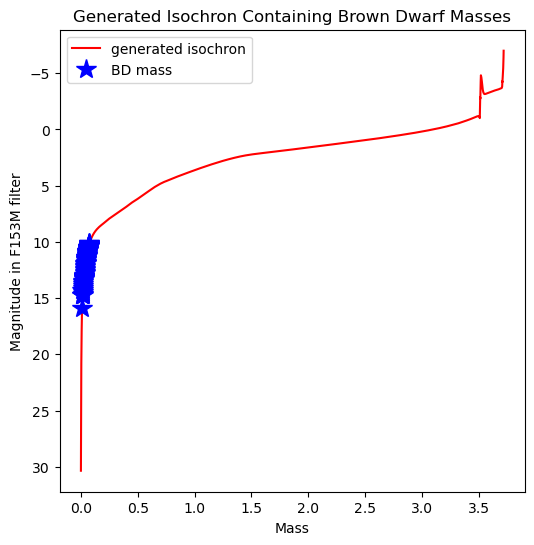

In [20]:
# Make a mass-magnitude diagram from the isochrone and plot brown dwarfs
py.figure(1, figsize=(6,6))
py.clf()
py.plot(my_iso.points['mass'], my_iso.points['m_hst_f153m'], 'r-', label='generated isochron')
py.plot(my_iso.points['mass'][bd_idx], my_iso.points['m_hst_f153m'][bd_idx], 'b*', ms=15, label='BD mass')
py.title('Generated Isochron Containing Brown Dwarf Masses')
py.xlabel('Mass')
py.ylabel('Magnitude in F153M filter')
py.gca().invert_yaxis()
py.legend()
py.show()

### Brown Dwarfs in Simulated Clusters

We will now use our generated isochrone to pinpoint brown dwarfs in clusters. An easy way to do this is through the 'phase' column, where brown dwarfs are assigned a value of 90. We will see how their numbers and evolution compares to compact objects.

In [21]:
# Create IMF objects                                                                                                                                                     
imf_multi = multiplicity.MultiplicityUnresolved()
kc_imf = imf.Salpeter_Kirkpatrick_2024(multiplicity=imf_multi)

In [22]:
# Make cluster
cluster_mass = 10**6
kc_cluster = synthetic.ResolvedCluster(my_iso, kc_imf, cluster_mass, ifmr=my_ifmr)

# Get outputs
kc_out = kc_cluster.star_systems
kc_comp = kc_cluster.companions

Found 12259 companions out of stellar mass range


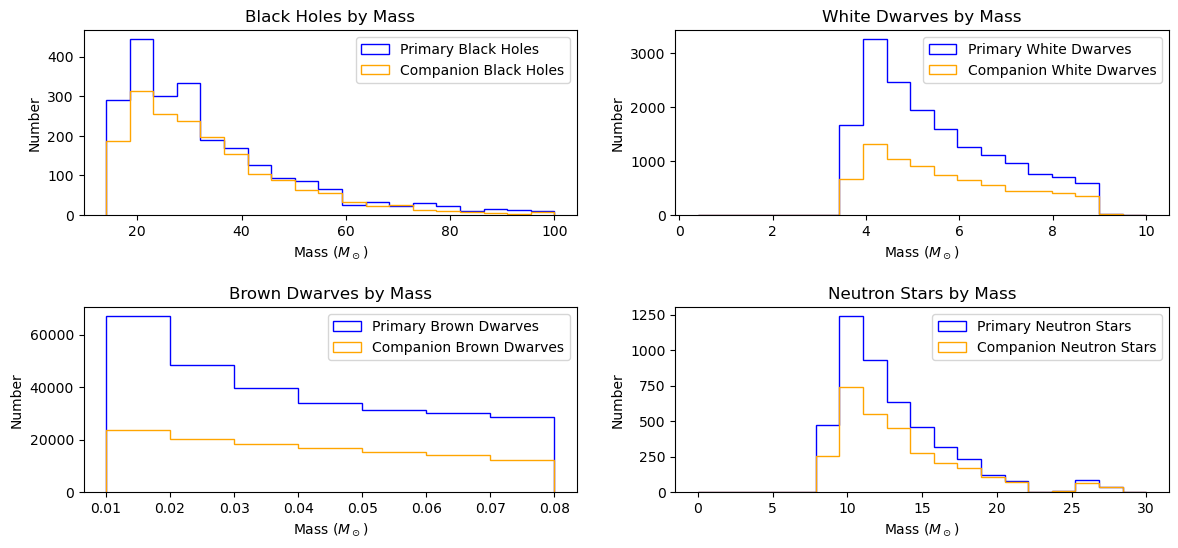

In [23]:
# Locate BHs, NSs, WDs, and BDs
p2_bh = np.where(kc_out['phase'] == 103)[0]
c_bh = np.where(kc_comp['phase'] == 103)[0]
p2_ns = np.where(kc_out['phase'] == 102)[0]
c_ns = np.where(kc_comp['phase'] == 102)[0]
p2_wd = np.where(kc_out['phase'] == 101)[0]
c_wd = np.where(kc_comp['phase'] == 101)[0]
p2_bd = np.where(kc_out['phase'] == 90)[0]
c_bd = np.where(kc_comp['phase'] == 90)[0]

# Define bins for histograms
bh_bins = np.linspace(14, 100, 20)
wd_bins = np.linspace(0.4, 10, 20)
bd_bins = np.linspace(0.01, 0.08, 8)
ns_bins = np.linspace(0, 30, 20)

# Create subplots
plt.figure(figsize=(14,6))

# Plot BHs
plt.subplot(2, 2, 1)
plt.hist(kc_out[p2_bh]['mass'], histtype='step', bins=bh_bins, label='Primary Black Holes', color='blue')
plt.hist(kc_comp[c_bh]['mass'], histtype='step', bins=bh_bins, label='Companion Black Holes', color='orange')
plt.title("Black Holes by Mass")
plt.xlabel('Mass ($M_\odot$)')
plt.ylabel('Number')
plt.legend()

# Plot WDs
plt.subplot(2, 2, 2)
plt.hist(kc_out[p2_wd]['mass'], histtype='step', bins=wd_bins, label='Primary White Dwarves', color='blue')
plt.hist(kc_comp[c_wd]['mass'], histtype='step', bins=wd_bins, label='Companion White Dwarves', color='orange')
plt.title("White Dwarves by Mass")
plt.xlabel('Mass ($M_\odot$)')
plt.ylabel('Number')
plt.legend()

# Plot BDs
plt.subplot(2, 2, 3)
plt.hist(kc_out[p2_bd]['mass'], histtype='step', bins=bd_bins, label='Primary Brown Dwarves', color='blue')
plt.hist(kc_comp[c_bd]['mass'], histtype='step', bins=bd_bins, label='Companion Brown Dwarves', color='orange')
plt.title("Brown Dwarves by Mass")
plt.xlabel('Mass ($M_\odot$)')
plt.ylabel('Number')
plt.legend()

# Plot NSs
plt.subplot(2, 2, 4)
plt.hist(kc_out[p2_ns]['mass'], histtype='step', bins=ns_bins, label='Primary Neutron Stars', color='blue')
plt.hist(kc_comp[c_ns]['mass'], histtype='step', bins=ns_bins, label='Companion Neutron Stars', color='orange')
plt.title("Neutron Stars by Mass")
plt.xlabel('Mass ($M_\odot$)')
plt.ylabel('Number')
plt.legend()

# Adjust space between subplots
plt.subplots_adjust(hspace=0.5)

# Show the plots
plt.show()


Plotted above are the number of generated compact objects (black holes, white dwarfs, and neutron stars) against the generated number of brown dwarfs.

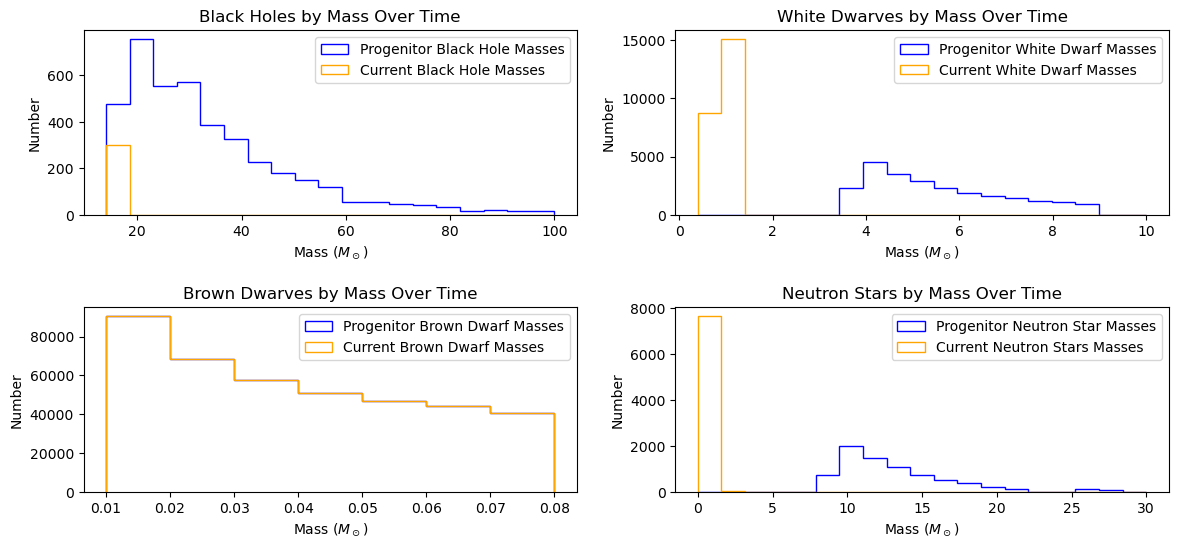

In [24]:
# Locate BHs, NSs, WDs, and BDs
p2_bh = np.where(kc_out['phase'] == 103)[0]
c_bh = np.where(kc_comp['phase'] == 103)[0]
k_bh = vstack([kc_out[p2_bh], kc_comp[c_bh]])
p2_ns = np.where(kc_out['phase'] == 102)[0]
c_ns = np.where(kc_comp['phase'] == 102)[0]
k_ns = vstack([kc_out[p2_ns], kc_comp[c_ns]])
p2_wd = np.where(kc_out['phase'] == 101)[0]
c_wd = np.where(kc_comp['phase'] == 101)[0]
k_wd = vstack([kc_out[p2_wd], kc_comp[c_wd]])
p2_bd = np.where(kc_out['phase'] == 90)[0]
c_bd = np.where(kc_comp['phase'] == 90)[0]
k_bd = vstack([kc_out[p2_bd], kc_comp[c_bd]])

# Create subplots
plt.figure(figsize=(14,6))

# Plot BHs
plt.subplot(2, 2, 1)
plt.hist(k_bh['mass'], histtype='step', bins=bh_bins, label='Progenitor Black Hole Masses', color='blue')
plt.hist(k_bh['mass_current'], histtype='step', bins=bh_bins, label='Current Black Hole Masses', color='orange')
plt.title("Black Holes by Mass Over Time")
plt.xlabel('Mass ($M_\odot$)')
plt.ylabel('Number')
plt.legend()

# Plot WDs
plt.subplot(2, 2, 2)
plt.hist(k_wd['mass'], histtype='step', bins=wd_bins, label='Progenitor White Dwarf Masses', color='blue')
plt.hist(k_wd['mass_current'], histtype='step', bins=wd_bins, label='Current White Dwarf Masses', color='orange')
plt.title("White Dwarves by Mass Over Time")
plt.xlabel('Mass ($M_\odot$)')
plt.ylabel('Number')
plt.legend()

# Plot BDs
plt.subplot(2, 2, 3)
plt.hist(k_bd['mass'], histtype='step', bins=bd_bins, label='Progenitor Brown Dwarf Masses', color='blue')
plt.hist(k_bd['mass_current'], histtype='step', bins=bd_bins, label='Current Brown Dwarf Masses', color='orange')
plt.title("Brown Dwarves by Mass Over Time")
plt.xlabel('Mass ($M_\odot$)')
plt.ylabel('Number')
plt.legend()

# Plot NSs
plt.subplot(2, 2, 4)
plt.hist(k_ns['mass'], histtype='step', bins=ns_bins, label='Progenitor Neutron Star Masses', color='blue')
plt.hist(k_ns['mass_current'], histtype='step', bins=ns_bins, label='Current Neutron Stars Masses', color='orange')
plt.title("Neutron Stars by Mass Over Time")
plt.xlabel('Mass ($M_\odot$)')
plt.ylabel('Number')
plt.legend()

# Adjust space between subplots
plt.subplots_adjust(hspace=0.5)

# Show the plots
plt.show()


Above we have plotted the initial masses of compact objects (black holes, neutron stars, and white dwarfs) against their current masses. We have done the same for brown dwarfs. As expected, brown dwarf masses do not change over time.